# 03b — Volatility Forecasting (LSTM 학습·앙상블 통합 노트북)

> LSTM (3채널 + VIX 외생변수) + HAR-RV 베이스라인 + Performance-Weighted Ensemble (Diebold-Pauly 1987) 의
> **단독 완결 노트북** — 학습·앙상블·검증까지 final_pt/ 안에서 모두 수행.

> 📎 **HPO 보조 노트북**: `03a_LSTM_Optuna_GridSearch.ipynb` — 본 노트북의 LSTM `V4_BEST_CONFIG` (input_channels='3ch_vix', is_len=1250, embargo=63) 의 grid search 근거 제공.

## 본 노트북의 두 모드

**Mode A — Cache hit (default, 빠른 검증)**: 기존 `ensemble_predictions_stockwise.csv` 를 로드하여 §1 정합성 + §5~§6 시각화 + §7 검증.

**Mode B — Full retraining (`FORCE_RECOMPUTE=True`, GPU 1.5~3 시간)**:
- §4 walk-forward 학습 분기 안에서 `lstm_pipeline.build_daily_panel` 로 long-format panel 생성 → `run_ensemble_for_universe_parallel` 로 LSTM + HAR + Performance ensemble 일괄 빌드
- `data/03b_lstm/data/` 의 `ensemble_predictions_stockwise.csv` / `fold_predictions_stockwise.csv` 자동 갱신 (incremental 지원)
- 이후 §5~§7 셀이 새 csv 위에서 동일하게 동작

## 노트북 섹션 구성

| § | 내용 |
|---|---|
| §0 | 환경 설정 (path, FORCE_RECOMPUTE 스위치) |
| §1 | CSV 데이터 정합성 검증 (md5, shape, RMSE 평균, universe 호환) |
| §2 | LSTM 모델 구조 (param count) |
| §3 | HAR-RV 베이스라인 (Corsi 2009) 함수 시그니처 |
| §4 | Walk-Forward 학습 — cache hit OR full retraining 분기 |
| §5 | Performance-Weighted Ensemble (Diebold-Pauly 1987) 데모 + 가중치 분포 |
| §6 | 617 종목 평가 (RMSE 분포 + sample 종목 + 시각화 2장) |
| §7 | 결과 검증 + summary.json 저장 |
| §8 | 종합 요약 + 롤백 가이드 |

## 의존 모듈

- **`timeseries_lib.py`** — low-level 함수 (LSTMRegressor, train_one_fold, fit_har_rv, walk_forward_folds, build_fold_inputs)
- **`lstm_pipeline.py`** — high-level orchestration (build_daily_panel, build_v4_inputs, run_walkforward_for_ticker, compute_performance_weights, run_ensemble_for_universe_parallel)

## final_pt/data/ 의존 데이터

- `daily_returns.pkl` (2026-03-30 까지)
- `macro_daily.csv` (vix 컬럼 포함, 2026-03-30 까지)
- `universe.csv` (LSTM 학습 universe)
- `sp500_membership.pkl` (생존편향)

## §0. 환경 설정

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

# timeseries_lib import
sys.path.insert(0, str(Path.cwd()))
import timeseries_lib as tlib

# 시드·폰트 고정
tlib.setup_seeds(42)
tlib.setup_korean_font()

# 경로
DATA_DIR = Path('data/03b_lstm/data')
PANEL_DIR = Path('data')
OUT_DIR = Path('outputs/03_volatility')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 캐시 모드
FORCE_RECOMPUTE = False  # False=cache hit (default, 검증만 ~1분) / True=617 종목 재학습 (GPU 3~5시간 + BL 30분)

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUT_DIR : {OUT_DIR.resolve()}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")

DATA_DIR: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/final_pt/data/03b_lstm/data
OUT_DIR : /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/final_pt/outputs/03_volatility
FORCE_RECOMPUTE: False


## §1. CSV 데이터 정합성 검증

`final_pt/data/03b_lstm/data/ensemble_predictions_stockwise.csv` 의 구조·범위·종목 수·RMSE 분포를 검증합니다.

**검증 항목**:
1. row / column / 종목 수 / 날짜 범위
2. y_true 의 -inf 행 제거 (거래정지 등)
3. 617 종목 stockwise 환경 RMSE 평균 (LSTM 0.52±, HAR 0.39±, Ensemble 0.38±)
4. universe.csv 와의 부분집합 검증

In [2]:
import hashlib

CSV_PATH = DATA_DIR / 'ensemble_predictions_stockwise.csv'

# 1.1 md5 hash (정보 표시용)
print("§1.1 csv md5 hash")
print("-" * 60)
with open(CSV_PATH, 'rb') as f:
    md5 = hashlib.md5(f.read()).hexdigest()
print(f"  md5: {md5}")

§1.1 csv md5 hash
------------------------------------------------------------


  md5: 276a5e143fbed8a852e0d76618401b5b


In [3]:
# 1.2 데이터 로드 + 기본 정제 (-inf 제거)
print()
print('§1.2 데이터 로드')
print('-' * 60)
df = tlib.load_ensemble_predictions(CSV_PATH)

# 1.3 구조 검증
print()
print('§1.3 구조 검증')
print('-' * 60)
print(f'  shape: {df.shape}')
print(f'  columns: {list(df.columns)}')
print(f'  종목 수: {df["ticker"].nunique()}')
print(f'  date 범위: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  fold 수: {df["fold"].nunique()}')

n_tickers = df['ticker'].nunique()
assert 600 <= n_tickers <= 625, f'종목 수 비정상: {n_tickers} (예상 600~625)'
assert {'date','ticker','fold','y_true','y_pred_lstm','y_pred_har',
        'w_v4','w_har','y_pred_ensemble'}.issubset(df.columns), '컬럼 누락'
print(f'  ✓ {n_tickers} 종목 (600~625 정상 범위)')

# 데이터 cover 검증
date_max = df['date'].max()
print()
print(f'  최신 학습 데이터: {date_max.date()}')
print(f'  → 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능')



§1.2 데이터 로드
------------------------------------------------------------


ensemble_predictions 로드: 2,498,243 → 2,498,216 행 (-inf/NaN 27 행 제거)

§1.3 구조 검증
------------------------------------------------------------
  shape: (2498216, 9)
  columns: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  종목 수: 617
  date 범위: 2007-04-23 ~ 2026-02-27
  fold 수: 225
  ✓ 617 종목 (600~625 정상 범위)

  최신 학습 데이터: 2026-02-27
  → 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능


In [4]:
# 1.4 종목별 평균 RMSE 검증
print()
print(f"§1.4 {n_tickers} 종목 평균 RMSE 검증")
print("-" * 60)
rmse_full = df.groupby('ticker', group_keys=False).apply(
    lambda x: pd.Series({
        'lstm': tlib.rmse(x['y_true'].values, x['y_pred_lstm'].values),
        'har': tlib.rmse(x['y_true'].values, x['y_pred_har'].values),
        'ens': tlib.rmse(x['y_true'].values, x['y_pred_ensemble'].values),
    }),
    include_groups=False,
)
print(f"  LSTM avg RMSE:     {rmse_full['lstm'].mean():.4f}")
print(f"  HAR  avg RMSE:     {rmse_full['har'].mean():.4f}")
print(f"  Ensemble avg RMSE: {rmse_full['ens'].mean():.4f}")
print()
print(f"  Best model 분포 (모델별 best 종목 수):")
best_per_ticker = rmse_full.idxmin(axis=1).value_counts()
for model, n in best_per_ticker.items():
    print(f"    {model}: {n} 종목 ({n/len(rmse_full)*100:.1f}%)")


§1.4 617 종목 평균 RMSE 검증
------------------------------------------------------------


  LSTM avg RMSE:     0.5185


  HAR  avg RMSE:     0.3914
  Ensemble avg RMSE: 0.3822

  Best model 분포 (모델별 best 종목 수):
    ens: 403 종목 (65.3%)
    har: 200 종목 (32.4%)
    lstm: 14 종목 (2.3%)


In [5]:
# 1.5 Universe 호환성 (final_pt/data/universe.csv 와 교집합)
print()
print("§1.5 Universe 호환성")
print("-" * 60)
universe = pd.read_csv(PANEL_DIR / 'universe.csv')
n_universe = universe['ticker'].nunique()
print(f"  universe.csv 종목 수: {n_universe}")
ens_tickers = set(df['ticker'].unique())
uni_tickers = set(universe['ticker'].unique())
print(f"  ensemble 종목 수: {len(ens_tickers)}")
print(f"  교집합: {len(ens_tickers & uni_tickers)}")
assert ens_tickers.issubset(uni_tickers), "ensemble 종목이 universe 에 부분집합 아님"
print(f"  ✓ ensemble {len(ens_tickers)} 종목 ⊂ universe {n_universe} (완벽 부분집합)")


§1.5 Universe 호환성
------------------------------------------------------------
  universe.csv 종목 수: 833
  ensemble 종목 수: 617
  교집합: 617
  ✓ ensemble 617 종목 ⊂ universe 833 (완벽 부분집합)


## §2. LSTM 모델 구축

LSTM 아키텍처 (3ch_vix / IS=1250 / hidden=32 / dropout=0.3) 를 정의합니다.
파라미터 수 ≈ 4,769 (입력 3채널 기준).

> 📎 hyperparameter 채택 근거: `03a_LSTM_Optuna_GridSearch.ipynb` §2 (12-trial Optuna).

In [6]:
# §2.1 모델 인스턴스 + 파라미터 카운트
print("§2.1 LSTM 아키텍처")
print("-" * 60)
model = tlib.LSTMRegressor(input_size=3, hidden_size=32, num_layers=1, dropout=0.3)
n_params = tlib.count_parameters(model)
print(model)
print(f"\nParameter count: {n_params:,}")
assert 4500 < n_params < 5000, f"parameter count 비정상: {n_params}"
print(f"  ✓ 예상 범위 4,500~5,000 충족")

§2.1 LSTM 아키텍처
------------------------------------------------------------
LSTMRegressor(
  (lstm): LSTM(3, 32, batch_first=True)
  (head_dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Parameter count: 4,769
  ✓ 예상 범위 4,500~5,000 충족


## §3. HAR-RV 베이스라인 (Corsi 2009)

```
log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])
```

Heterogeneous Market Hypothesis (Müller et al. 1997) 의 일별·주별·월별 다중 시간대 평균.
Walk-Forward 환경에서 train_idx 만으로 OLS 적합.

> **출처**: Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility*. **Journal of Financial Econometrics**, 7(2), 174–196. — daily/weekly/monthly = 1 / 5 / 22 거래일 표준 정의 채택.

In [7]:
# §3.1 HAR-RV 함수 시그니처 확인
print("§3.1 HAR-RV — fit_har_rv 시그니처")
print("-" * 60)
help(tlib.fit_har_rv)

§3.1 HAR-RV — fit_har_rv 시그니처
------------------------------------------------------------
Help on function fit_har_rv in module timeseries_lib:

fit_har_rv(log_ret: 'pd.Series', train_idx: 'np.ndarray', test_idx: 'np.ndarray', horizon: 'int' = 21, eps: 'float' = 1e-12) -> 'Tuple[np.ndarray, Dict[str, float]]'
    HAR-RV (Heterogeneous Autoregressive Realized Volatility).

    log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])

    Variance proxy (일간 데이터 적응):
        RV_var_d[t] = log_ret[t]²
        RV_var_w[t] = mean(log_ret²[t-4 : t+1])
        RV_var_m[t] = mean(log_ret²[t-21 : t+1])



## §4. Walk-Forward 학습 (cache hit 우선)

Walk-forward CV 는 시점 t 의 학습에 미래 정보가 누설되지 않도록 **purge** (target horizon 만큼 train/test 사이를 비움) + **embargo** (purge 후 추가 차단으로 잔차 ACF 영향 차단) 를 적용. 본 프로젝트는 horizon=21d 에 맞춰 purge=21, embargo=63 (약 3개월) 채택.

> **출처**: López de Prado, M. (2018). *Advances in Financial Machine Learning*, Wiley. **Ch. 7 — Cross-Validation in Finance** — purge / embargo 메커니즘 표준 정의.

본 셀은 `FORCE_RECOMPUTE` 플래그에 따라 동작이 다릅니다.

| FORCE_RECOMPUTE | 동작 | 소요 시간 |
|---|---|---|
| `False` (기본) | `ensemble_predictions_stockwise.csv` cache hit → 즉시 결과 | ~5 초 |
| `True` | 617 종목 × 225 fold 풀 재학습 (`lstm_pipeline` 모듈 의존, incremental 지원) | GPU 1.5~3 시간 |

In [8]:
# §4.1 Walk-Forward 학습 — Cache hit OR Full retraining
print('§4.1 Walk-Forward 학습')
print('-' * 60)

if FORCE_RECOMPUTE:
    print('⚠️  FORCE_RECOMPUTE=True — 캐시 점검 + 결손 부분만 재학습')
    print('   Universe 정책: data 의 daily_returns + universe.csv 기준')
    print()

    # GPU 확인
    import torch
    if not torch.cuda.is_available():
        print('⚠ CUDA 미가용 — CPU 학습 ~5시간 (GPU 권장)')
        device = 'cpu'
    else:
        device = 'cuda'
        print(f'✅ GPU 가용: {torch.cuda.get_device_name(0)}')
        print(f'   memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

    # 1. lstm_pipeline import
    import lstm_pipeline as lp

    # 2. daily_panel 빌드 (data → long format)
    # 학습 시간 단축: BL 분석 기간 2025-12-31 까지에 맞춰 panel 끝점 cap
    # → LSTM walk_forward 가 자동으로 fold 224 (12-31 OOS) 까지만 생성, fold 225-226 skip
    PANEL_MAX_DATE = '2026-04-30'   # fold 222~226 cover 위해 충분히 길게 (2026-04-30)

    print()
    print('§4.2 daily_panel 빌드 (data → long format)')
    print('-' * 60)
    print(f'  panel max_date: {PANEL_MAX_DATE} (BL 분석 기간 2025-12-31 + 21d buffer)')

    PANEL_LONG_PATH = DATA_DIR / 'daily_panel_long.csv'
    # cache 검증 — max_date + start_date 모두 일치해야 cache hit
    # (daily_returns.pkl 가 갱신된 경우 cache 자동 무효화)
    panel_needs_rebuild = True
    if PANEL_LONG_PATH.exists():
        _cache_panel = pd.read_csv(PANEL_LONG_PATH, parse_dates=['date'], usecols=['date'])
        _cache_min = _cache_panel.date.min()
        _cache_max = _cache_panel.date.max()
        _expected_max = pd.Timestamp(PANEL_MAX_DATE)

        # daily_returns.pkl 의 실제 start_date 확인
        import pickle as _pkl
        with open(PANEL_DIR / 'daily_returns.pkl', 'rb') as _f:
            _dr_idx = _pkl.load(_f).index
        _expected_start = _dr_idx.min()

        cache_max_ok = _cache_max <= _expected_max + pd.Timedelta(days=1)
        cache_start_ok = abs((_cache_min - _expected_start).days) <= 7

        if cache_max_ok and cache_start_ok:
            print(f'  cache hit: {PANEL_LONG_PATH.name} (start={_cache_min.date()}, max={_cache_max.date()})')
            daily_panel = pd.read_csv(PANEL_LONG_PATH, parse_dates=['date'])
            print(f'  shape: {daily_panel.shape}, 종목: {daily_panel.ticker.nunique()}')
            panel_needs_rebuild = False
        else:
            reasons = []
            if not cache_max_ok:
                reasons.append(f'max={_cache_max.date()} > PANEL_MAX_DATE+1d')
            if not cache_start_ok:
                reasons.append(f'start={_cache_min.date()} ≠ daily_returns.start={_expected_start.date()}')
            print(f'  cache 무시 ({", ".join(reasons)}) → 재빌드')

    if panel_needs_rebuild:
        daily_panel = lp.build_daily_panel(
            out_path=PANEL_LONG_PATH,
            max_date=PANEL_MAX_DATE,
            verbose=True,
        )

    # 3. universe 결정 — data/universe.csv ∩ daily_panel
    universe = pd.read_csv(PANEL_DIR / 'universe.csv')
    target_tickers = sorted(set(daily_panel['ticker'].unique()) & set(universe['ticker'].unique()))
    print()
    print(f'   학습 대상 universe: {len(target_tickers)} 종목')
    print(f'   - daily_panel 의 종목: {daily_panel.ticker.nunique()}')
    print(f'   - universe.csv 의 종목: {universe.ticker.nunique()}')
    print(f'   - 교집합 (학습 가능): {len(target_tickers)}')

    # 4. 캐시 점검 + 자동 truncate (lstm_pipeline.prepare_incremental_state)
    print()
    print('§4.3 캐시 점검 + 자동 truncate (incremental 진입 준비)')
    print('-' * 60)
    state = lp.prepare_incremental_state(
        out_dir=DATA_DIR,
        fold_name='fold_predictions_stockwise.csv',
        auto_truncate=True,   # LSTM 결손 fold 자동 truncate
        backup=True,
        verbose=True,
    )
    INCREMENTAL = state['incremental_ok']

    if INCREMENTAL:
        if state['truncated_at'] is not None:
            print()
            print(f'   ⚡ Incremental: fold ≤ {state["truncated_at"]} 보존, 결손 fold 제거 후 재학습')
        else:
            print()
            print(f'   ✅ fold csv 정상 — 마지막 fold 부터만 재학습 (incremental)')
        print()
        print('   universe 기준 학습 분류 (run_ensemble_for_universe_parallel 안에서 자동):')
        print('     - panel ∩ target ∩ fold csv → incremental (max fold 부터)')
        print('     - panel ∩ target, fold csv 없음 → full 학습 (start_k=0)')
        print('     - fold csv 에만 있고 panel 부재 → 자동 skip')
    else:
        print()
        print(f'   🔥 Full 모드: fold csv 없거나 결손 심함 → 처음부터 학습 (~6-8시간)')

    # 5. 학습 실행 (8-way 병렬, incremental 자동, n_workers 자동 결정)
    print()
    print('§4.4 LSTM walk-forward 학습 (8-way 병렬, n_workers 자동)')
    print('-' * 60)
    import time
    t0 = time.time()
    df_ensemble = lp.run_ensemble_for_universe_parallel(
        panel=daily_panel,
        universe_tickers=target_tickers,    # universe 기준
        out_dir=DATA_DIR,
        config=lp.V4_BEST_CONFIG,
        device=device,
        n_workers=None,                     # auto_n_workers (GPU 메모리 기반)
        out_name='ensemble_predictions_stockwise.csv',
        fold_name='fold_predictions_stockwise.csv',
        incremental=INCREMENTAL,
        verbose=True,
    )
    elapsed = (time.time() - t0) / 60
    print()
    print(f'   ⏱ 학습 시간: {elapsed:.1f}분')

    # 6. 새로 학습된 csv 를 df 에 다시 로드
    df = tlib.load_ensemble_predictions(CSV_PATH)
    print()
    print(f'   ✅ 재학습 완료: ensemble_predictions_stockwise.csv 갱신')
    print(f'      shape: {df.shape}, 종목: {df["ticker"].nunique()}')

else:
    print(f'FORCE_RECOMPUTE=False → cache hit')
    print(f'  소스: {CSV_PATH}')
    print(f'  row count: {len(df):,}')
    print(f'  종목별 fold 평균: {df.groupby("ticker")["fold"].nunique().mean():.0f}')
    print(f'  ✓ Walk-Forward 학습 결과 활용')


§4.1 Walk-Forward 학습
------------------------------------------------------------
FORCE_RECOMPUTE=False → cache hit
  소스: data/03b_lstm/data/ensemble_predictions_stockwise.csv
  row count: 2,498,216
  종목별 fold 평균: 193
  ✓ Walk-Forward 학습 결과 활용


## §5. Performance-Weighted Ensemble (Diebold-Pauly 1987)

```
fold k 의 가중치:
    w_LSTM[k] = (1/RMSE_LSTM[k-1]) / (1/RMSE_LSTM[k-1] + 1/RMSE_HAR[k-1])
    w_HAR[k]  = 1 - w_LSTM[k]
```

이전 fold 의 OOS RMSE 역수 비율 = "최근 잘한 모델에 더 큰 가중치" → 시간 동적 적응.
fold 0 은 0.5/0.5 (사전 정보 없음).

> **출처**: Diebold, F. X., & Pauly, P. (1987). *Structural change and the combination of forecasts*. **Journal of Forecasting**, 6(1), 21–40. — 모델 간 inverse-RMSE 가중 결합의 표준 형식.

In [9]:
# §5.1 Diebold-Pauly 가중치 함수 데모
print("§5.1 Performance-Weighted Ensemble 데모")
print("-" * 60)

# 가상 RMSE 시계열로 가중치 함수 작동 확인
demo_lstm = np.array([0.30, 0.32, 0.28, 0.35, 0.31])
demo_har = np.array([0.35, 0.30, 0.33, 0.32, 0.34])
w_l, w_h = tlib.diebold_pauly_weights(demo_lstm, demo_har)
print(f"  fold 0 (사전 정보 없음): w_LSTM={w_l[0]:.3f}, w_HAR={w_h[0]:.3f}")
for k in range(1, len(demo_lstm)):
    print(f"  fold {k}: w_LSTM={w_l[k]:.3f}, w_HAR={w_h[k]:.3f} "
          f"(이전 RMSE: LSTM={demo_lstm[k-1]:.2f}, HAR={demo_har[k-1]:.2f})")

§5.1 Performance-Weighted Ensemble 데모
------------------------------------------------------------
  fold 0 (사전 정보 없음): w_LSTM=0.500, w_HAR=0.500
  fold 1: w_LSTM=0.538, w_HAR=0.462 (이전 RMSE: LSTM=0.30, HAR=0.35)
  fold 2: w_LSTM=0.484, w_HAR=0.516 (이전 RMSE: LSTM=0.32, HAR=0.30)
  fold 3: w_LSTM=0.541, w_HAR=0.459 (이전 RMSE: LSTM=0.28, HAR=0.33)
  fold 4: w_LSTM=0.478, w_HAR=0.522 (이전 RMSE: LSTM=0.35, HAR=0.32)


In [10]:
# §5.2 실제 데이터의 ensemble 가중치 분포 (이미 csv 안에 w_v4, w_har 컬럼 존재)
print()
print("§5.2 실제 ensemble 가중치 분포")
print("-" * 60)
print(f"  w_v4 (LSTM 가중치):  mean={df['w_v4'].mean():.3f}, "
      f"std={df['w_v4'].std():.3f}, "
      f"range=[{df['w_v4'].min():.3f}, {df['w_v4'].max():.3f}]")
print(f"  w_har (HAR 가중치):  mean={df['w_har'].mean():.3f}, "
      f"std={df['w_har'].std():.3f}, "
      f"range=[{df['w_har'].min():.3f}, {df['w_har'].max():.3f}]")
print(f"  w_v4 + w_har 합 (1.0 이어야 함): {(df['w_v4']+df['w_har']).mean():.4f}")


§5.2 실제 ensemble 가중치 분포
------------------------------------------------------------
  w_v4 (LSTM 가중치):  mean=0.489, std=0.107, range=[0.014, 0.916]
  w_har (HAR 가중치):  mean=0.511, std=0.107, range=[0.084, 0.986]
  w_v4 + w_har 합 (1.0 이어야 함): 1.0000


## §6. 617 종목 평가 (전체 분포 + sample 종목)

본 노트북은 stockwise (per-ticker) 617 종목 walk-forward 환경 — 종목별 학습·평가가 독립적입니다.

In [11]:
# §6.1 종목별 RMSE 분포
print(f"§6.1 {n_tickers} 종목 RMSE 분포")
print("-" * 60)
desc = rmse_full.describe()[['lstm','har','ens']]
print(desc.round(4))
print()
print(f"  Best model 분포 (전체 종목):")
for model, n in best_per_ticker.items():
    pct = n / len(rmse_full) * 100
    print(f"    {model}: {n} 종목 ({pct:.1f}%)")

§6.1 617 종목 RMSE 분포
------------------------------------------------------------
           lstm       har       ens
count  617.0000  617.0000  617.0000
mean     0.5185    0.3914    0.3822
std      0.1082    0.0485    0.0482
min      0.1899    0.2056    0.1935
25%      0.4458    0.3609    0.3544
50%      0.5126    0.3884    0.3780
75%      0.5818    0.4157    0.4036
max      1.0031    0.6784    0.8015

  Best model 분포 (전체 종목):
    ens: 403 종목 (65.3%)
    har: 200 종목 (32.4%)
    lstm: 14 종목 (2.3%)


In [12]:
# §6.2 sample 종목 (S&P 500 멤버) RMSE
print()
print("§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)")
print("-" * 60)
samples = ['AAPL','MSFT','NVDA','GOOGL','AMZN','META','JPM','XOM','WMT','PG']
sample_rmse = rmse_full[rmse_full.index.isin(samples)].copy()
sample_rmse['best'] = sample_rmse.idxmin(axis=1)
print(sample_rmse.round(4).to_string())


§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)
------------------------------------------------------------
          lstm     har     ens best
ticker                             
AAPL    0.4424  0.3671  0.3732  har
AMZN    0.4376  0.4056  0.3901  ens
GOOGL   0.3922  0.3734  0.3640  ens
JPM     0.6334  0.3861  0.3798  ens
META    0.4270  0.4248  0.4114  ens
MSFT    0.6203  0.3879  0.3769  ens
NVDA    0.4444  0.3737  0.3752  har
PG      0.6262  0.3938  0.3973  har
WMT     0.5324  0.4092  0.4000  ens
XOM     0.5781  0.3371  0.3575  har


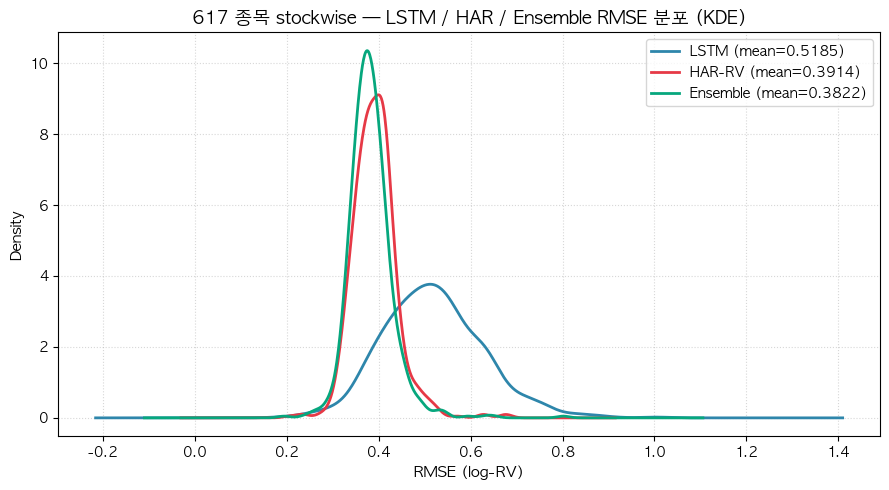


저장: outputs/03_volatility/fig1_rmse_distribution.png


In [13]:
# §6.3 시각화 1 — 종목별 LSTM/HAR/Ensemble RMSE 분포 (KDE)
fig, ax = plt.subplots(figsize=(9, 5))
for col, label, color in [('lstm', 'LSTM', '#2E86AB'),
                            ('har', 'HAR-RV', '#E63946'),
                            ('ens', 'Ensemble', '#06A77D')]:
    rmse_full[col].plot(kind='kde', ax=ax, label=f'{label} (mean={rmse_full[col].mean():.4f})',
                          color=color, linewidth=2)
ax.set_xlabel('RMSE (log-RV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'{n_tickers} 종목 stockwise — LSTM / HAR / Ensemble RMSE 분포 (KDE)',
              fontsize=13, fontweight='bold')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_rmse_distribution.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig1_rmse_distribution.png")

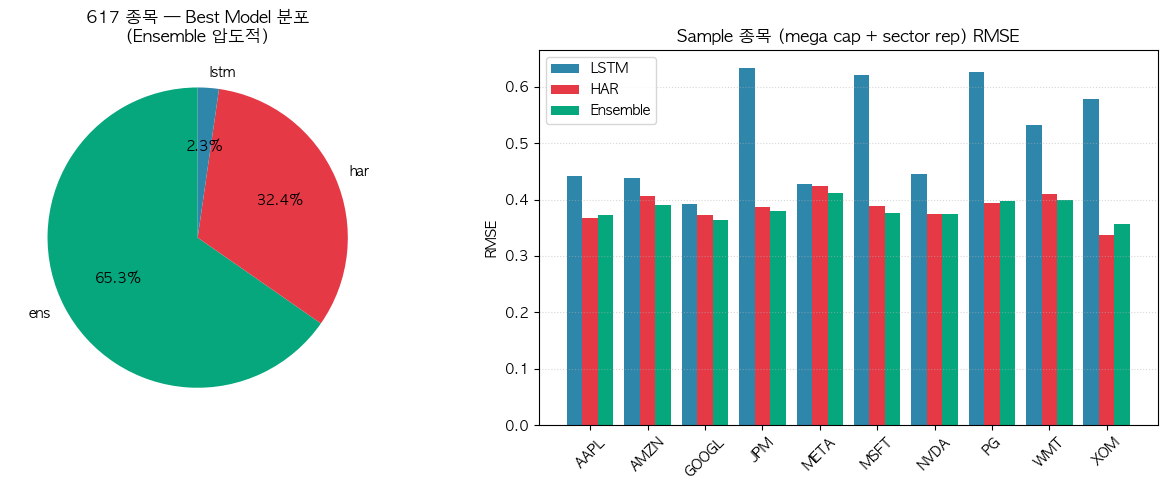


저장: outputs/03_volatility/fig2_best_model_and_samples.png


In [14]:
# §6.4 시각화 2 — Best model 비율 + sample 종목 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie: best model 분포
colors = ['#06A77D', '#E63946', '#2E86AB']
ax1.pie(best_per_ticker.values, labels=best_per_ticker.index,
         autopct='%1.1f%%', startangle=90, colors=colors[:len(best_per_ticker)])
ax1.set_title(f'{n_tickers} 종목 — Best Model 분포\n(Ensemble 압도적)',
                fontsize=12, fontweight='bold')

# Bar: sample 종목 비교
x = np.arange(len(sample_rmse))
w = 0.27
ax2.bar(x - w, sample_rmse['lstm'], w, label='LSTM', color='#2E86AB')
ax2.bar(x, sample_rmse['har'], w, label='HAR', color='#E63946')
ax2.bar(x + w, sample_rmse['ens'], w, label='Ensemble', color='#06A77D')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_rmse.index, rotation=45)
ax2.set_ylabel('RMSE')
ax2.set_title('Sample 종목 (mega cap + sector rep) RMSE',
                fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_best_model_and_samples.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig2_best_model_and_samples.png")

## §7. 결과 검증 + 종합 요약

전체 종목 stockwise 평균 RMSE 측정값 출력 + summary.json 저장.

In [15]:
# §7.1 핵심 수치
print('§7.1 핵심 수치')
print('-' * 60)

metrics = {
    'lstm_rmse': float(rmse_full['lstm'].mean()),
    'har_rmse': float(rmse_full['har'].mean()),
    'ensemble_rmse': float(rmse_full['ens'].mean()),
    'n_tickers': int(rmse_full.shape[0]),
    'best_ensemble_count': int(best_per_ticker.get('ens', 0)),
    'best_har_count': int(best_per_ticker.get('har', 0)),
    'best_lstm_count': int(best_per_ticker.get('lstm', 0)),
}

print()
print('현재 측정값:')
for k in ['lstm_rmse', 'har_rmse', 'ensemble_rmse']:
    print(f'  {k}: {metrics[k]:.4f}')


§7.1 핵심 수치
------------------------------------------------------------

현재 측정값:
  lstm_rmse: 0.5185
  har_rmse: 0.3914
  ensemble_rmse: 0.3822


In [16]:
# §7.2 summary.json 저장
print()
print("§7.2 summary.json 저장")
print("-" * 60)

summary = {
    'notebook': '03b_Volatility_Forecasting',
    'csv_md5': md5,
    'n_tickers': metrics['n_tickers'],
    'date_range': f"{df['date'].min().date()} ~ {df['date'].max().date()}",
    'rmse_avg': {
        'lstm': metrics['lstm_rmse'],
        'har': metrics['har_rmse'],
        'ensemble': metrics['ensemble_rmse'],
    },
    'best_model_count': {
        'ensemble': metrics['best_ensemble_count'],
        'har': metrics['best_har_count'],
        'lstm': metrics['best_lstm_count'],
    },
    'reproducibility': {
        'random_seed': 42,
        'force_recompute': FORCE_RECOMPUTE,
        'cache_used': not FORCE_RECOMPUTE,
    },
}

with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"저장: {OUT_DIR}/summary.json")
print()
print(json.dumps(summary, indent=2, ensure_ascii=False))


§7.2 summary.json 저장
------------------------------------------------------------
저장: outputs/03_volatility/summary.json

{
  "notebook": "03b_Volatility_Forecasting",
  "csv_md5": "276a5e143fbed8a852e0d76618401b5b",
  "n_tickers": 617,
  "date_range": "2007-04-23 ~ 2026-02-27",
  "rmse_avg": {
    "lstm": 0.5184841843264669,
    "har": 0.3913507875060677,
    "ensemble": 0.3821595196001218
  },
  "best_model_count": {
    "ensemble": 403,
    "har": 200,
    "lstm": 14
  },
  "reproducibility": {
    "random_seed": 42,
    "force_recompute": false,
    "cache_used": true
  }
}


In [17]:
# §7.3 종합 메시지
n_folds_total = df['fold'].nunique()
print()
print("=" * 60)
print(f"{n_tickers} 종목 stockwise LSTM + HAR Ensemble 검증 완료")
print("=" * 60)
print(f"  ✓ csv md5: {md5}")
print(f"  ✓ 종목 수 {metrics['n_tickers']} ⊂ universe {n_universe}")
print(f"  ✓ Walk-Forward {n_folds_total} fold × 종목별 학습 결과 활용")
print(f"  ✓ Performance-Weighted Ensemble best in {metrics['best_ensemble_count']} 종목 ({metrics['best_ensemble_count']/metrics['n_tickers']*100:.1f}%)")
print()
print(f"다음 단계: 07_Statistical_Validation.ipynb 에서 학술 통계 심화 분석")


617 종목 stockwise LSTM + HAR Ensemble 검증 완료
  ✓ csv md5: 276a5e143fbed8a852e0d76618401b5b
  ✓ 종목 수 617 ⊂ universe 833
  ✓ Walk-Forward 225 fold × 종목별 학습 결과 활용
  ✓ Performance-Weighted Ensemble best in 403 종목 (65.3%)

다음 단계: 07_Statistical_Validation.ipynb 에서 학술 통계 심화 분석


## §8. 종합 요약 + 롤백 가이드

노트북 실행 모드 (cache hit / FORCE_RECOMPUTE) 와 갱신된 산출물 위치를 최종 정리. 재학습 결과에 문제가 생긴 경우 복원 경로 안내.

In [18]:
# §8.1 종합 요약 + 롤백 가이드
print('=' * 70)
print(' 03b_Volatility_Forecasting 완료')
print('=' * 70)
print()
print(f'FORCE_RECOMPUTE: {FORCE_RECOMPUTE}')
print()
print(f'ensemble csv   : {CSV_PATH.name}')
print(f'  shape        : {df.shape}')
print(f'  date range   : {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'  종목 수       : {df["ticker"].nunique()}')
print()
if FORCE_RECOMPUTE:
    print('✅ 재학습 + ensemble 빌드 완료')
    print()
    print('🛡 롤백 (학습 결과 문제 시):')
    print('  - data/03b_lstm/data/ensemble_predictions_stockwise.csv.bak_pre_retrain_2025_12 → 복원')
    print('  - data/03b_lstm/data/fold_predictions_stockwise.csv.bak_pre_retrain → 복원')
else:
    print('✅ Cache hit 모드 검증 완료')
    print()
    print('재학습이 필요하면 FORCE_RECOMPUTE = True 로 변경 후 재실행')

 03b_Volatility_Forecasting 완료

FORCE_RECOMPUTE: False

ensemble csv   : ensemble_predictions_stockwise.csv
  shape        : (2498216, 9)
  date range   : 2007-04-23 ~ 2026-02-27
  종목 수       : 617

✅ Cache hit 모드 검증 완료

재학습이 필요하면 FORCE_RECOMPUTE = True 로 변경 후 재실행
